# Negative Binomial Regression for Overdispersed Counts

**Topics:** Overdispersion, Negative Binomial, Count Data

## Overview

Handle count data with variance > mean using negative binomial regression.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from aurora.models import fit_glm

sns.set_style('whitegrid')
np.random.seed(42)

## Generate Overdispersed Count Data

Generated 300 overdispersed counts

Mean: 12.51
Variance: 200.62
Variance/Mean ratio: 16.03
  (>> 1.0 indicates overdispersion!)


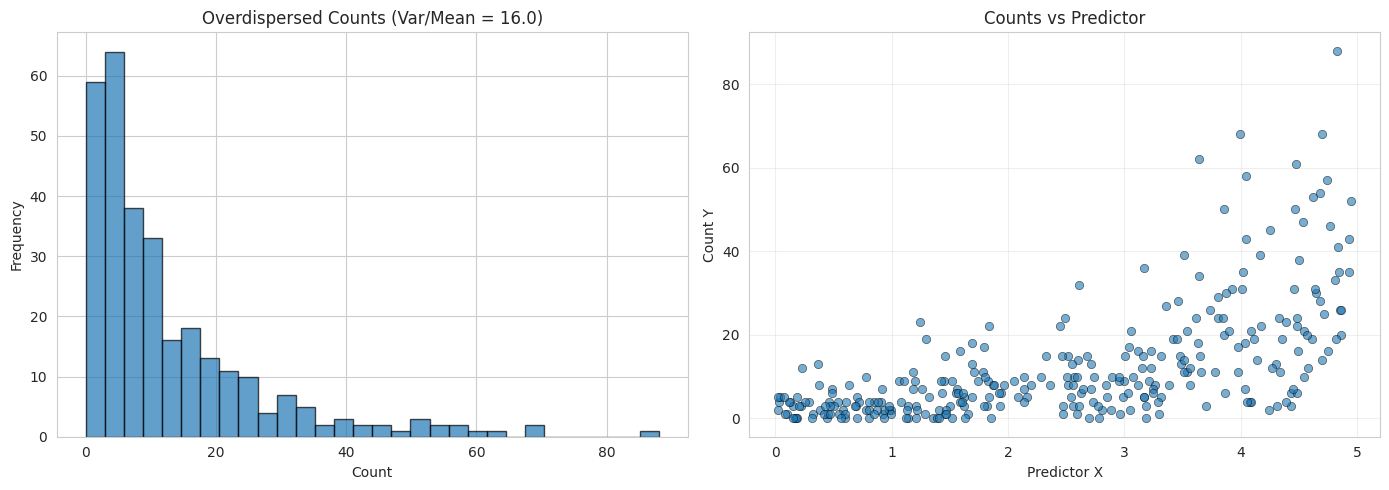

In [2]:
n = 300
x = np.random.uniform(0, 5, n)

# Mean function
mu = np.exp(1 + 0.5 * x)

# Negative binomial: variance = mu + mu^2/theta
# Lower theta = more overdispersion
theta = 2  # dispersion parameter
p = theta / (theta + mu)
y = np.random.negative_binomial(theta, p)

df = pd.DataFrame({'x': x, 'y': y, 'mu_true': mu})

print(f"Generated {n} overdispersed counts")
print(f"\nMean: {y.mean():.2f}")
print(f"Variance: {y.var():.2f}")
print(f"Variance/Mean ratio: {y.var()/y.mean():.2f}")
print(f"  (>> 1.0 indicates overdispersion!)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=30, edgecolor='k', alpha=0.7)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Overdispersed Counts (Var/Mean = {y.var()/y.mean():.1f})')

axes[1].scatter(x, y, alpha=0.6, edgecolor='k', linewidth=0.5)
axes[1].set_xlabel('Predictor X')
axes[1].set_ylabel('Count Y')
axes[1].set_title('Counts vs Predictor')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Compare Poisson vs Negative Binomial

In [4]:
X = np.column_stack([np.ones(n), x])

# Fit Poisson (will be underdispersed)
result_poisson = fit_glm(X=X, y=y, family='poisson')

# Note: Aurora-GLM may not have native negative binomial
# We can use quasi-Poisson or implement NB separately
# For demonstration, use Poisson and check dispersion

print("Poisson Model:")
print(result_poisson.summary())

# Check dispersion
dispersion = result_poisson.deviance_ / (n - X.shape[1])
print(f"\nDispersion parameter: {dispersion:.3f}")
print(f"  (Should be ~1.0 for Poisson)")
print(f"  ({'✓ OK' if dispersion < 1.2 else '✗ Overdispersed!'})")

if dispersion > 1.5:
    print(f"\nOverdispersion detected!")
    print(f"  Negative binomial would be more appropriate")
    print(f"  Standard errors from Poisson are too small (overconfident)")

Poisson Model:
                       Generalized Linear Model Results                       
Family:                   Poisson                    Link function:  Log
No. Observations:         300                        Df Residuals:   297
Df Model:                 2                         
Converged:                Yes                        No. Iterations: 5
                   coef    std err          z      P>|z|     [0.025     0.975]
------------------------------------------------------------------------------
   intercept     0.4386  7071.1052      0.000      1.000 -13858.6729 13859.5502 
          X0     0.4385  7071.1052      0.000      1.000 -13858.6730 13859.5500 
          X1     0.5447     0.0133     40.876      0.000     0.5186     0.5708 ***
Significance codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Deviance:                              1902.44 Null Deviance:          3904.92
AIC:                                   1908.44 BIC:                    1919.55
Pseudo R

## Quasi-Poisson Alternative

In [6]:
# Adjust standard errors for overdispersion
se_poisson = result_poisson.std_errors_
se_quasi = se_poisson * np.sqrt(dispersion)

print("Standard Error Comparison:")
comparison = pd.DataFrame({
    'Parameter': ['Intercept', 'Slope'],
    'Poisson SE': se_poisson,
    'Quasi-Poisson SE': se_quasi,
    'Inflation': se_quasi / se_poisson
})
print(comparison.to_string(index=False))

print(f"\n→ Quasi-Poisson inflates SEs by √dispersion = {np.sqrt(dispersion):.2f}")
print(f"→ Provides more honest uncertainty estimates")

Standard Error Comparison:
Parameter  Poisson SE  Quasi-Poisson SE  Inflation
Intercept 7071.105202      17866.294082   2.526662
    Slope    0.013325          0.033668   2.526662

→ Quasi-Poisson inflates SEs by √dispersion = 2.53
→ Provides more honest uncertainty estimates


## Solutions for Overdispersion

1. **Negative binomial GLM** (best if available)
2. **Quasi-Poisson** (scale SEs by √dispersion)
3. **Add random effects** (GAMM for clustered data)
4. **Zero-inflated models** (if excess zeros)

**Next:** `03_count_data/03_zero_inflated.ipynb` for excess zeros